# **Keras - Regressione con Reti Neurali**

**Panoramica**

In questa esercitazione il nostro compito sarà quello di eseguire una regressione tramite machine learning su dati rumorosi utilizzando una Rete Neurale (NN): esploreremo come la capacità di fit dipenda dalla struttura della NN.

**Il Problema della Predizione**

Consideriamo un processo probabilistico che genera dati etichettati $(x, y)$. I dati sono generati campionando dall'equazione:
$$y_i = f(x_i) + \eta_i$$
dove $f(x_i)$ è una funzione fissata (possibilmente ignota) e $\eta_i$ è una variabile di rumore gaussiano non correlato con media nulla. Dunque, aggiungendo il rumore, i punti non seguiranno più l'andamento della retta.

Per addestrare i parametri della NN, useremo un training set e poi testeremo l'efficacia della rete su un set di dati diverso, il validation set. Il motivo è che il machine learning serve a fare previsioni accurate su nuovi dati mai visti prima. Una misura comune della performance è l'errore quadratico medio (MSE) sul test set.

# **Esercizio 11.1**
**OBIETTIVI**

In questo esercizio viene chiesto di esplorare come la capacità di una rete neurale di effettuare una regressione lineare dipenda da tre parametri fondamentali: il numero di epoche, il numero di dati di training e il rumore gaussiano. L'obiettivo è partire dall'esempio presente nel notebook introduttivo e variare questi parametri per cercare di migliorare il fit della funzione target $f(x) = 2x + 1$.

**IMPLEMENTAZIONE**

*PARAMETRI CHIAVE*

-   **RUMORE**: i dati sono generati da una funzione target a cui viene aggiunto un rumore gaussiano non correlato, con media nulla. Se il rumore è alto, i dati saranno molto dispersi attorno alla funzione ideale, rendendo il fit più difficile.
-   **TRAINING E VALIDATION SET**: il dataset totale viene diviso in due gruppi:
      - TRAINING SET: è la porzione di dati usata effettivamente per addestrare il modello, ovvero per regolare i pesi e i bias affinché l'errore sia minimo.
      - VALIDATION SET: dati che la rete non ha mai visto durante l'allenamento. Servono a verificare se la rete ha davvero imparato la regola generale o se ha solo memorizzato i dati di training.
- **LOSS FUNCTION**: è la funzione matematica che l'algoritmo cerca di minimizzare durante l'apprendimento. Giudica quanto il modello stia performando bene:
  - MSE (Mean Squared Error): usato per la regressione, calcola la media dei quadrati delle differenze tra i valori predetti dalla rete e quelli reali. Dunque, MSE mi dice quanto la rete sbaglia mediamente.
- **ERRORE IN/OUT SAMPLE**: 
    - $E_{in}$ (Training Loss): l'errore misurato sul set di training. Tipicamente diminuisce all'aumentare dei dati o delle epoche.
  - $E_{out}$ (Validation Loss): l'errore misurato sul set di validazione. È il vero indicatore della capacità predittiva del modello, perchè dice quanto bene la rete funziona su dati mai visti
- **EPOCHE**: rappresentano il numero di volte che l'intero set di dati di training viene passato attraverso la rete neurale. In particolare, da un'epoca alla successiva la rete migliora i parametri di m e di b, e questo permette avvicinarsi di epoca in epoca alla retta vera.
    - Troppe epoche possono portare all'overfitting: la rete impara così bene i dettagli (e il rumore) del training set che smette di essere accurata sui dati nuovi ($E_{in}$ scende, ma $E_{out}$ inizia a risalire).
    - Early Stopping: è una tecnica che suggerisce di fermare l'allenamento nel punto in cui la validation loss è al minimo per evitare l'overfitting.


Per fare pratica con le reti neurali, devo esplorare come la regressione lineare precedente dipenda da:
*   Il numero di epoche ($N_{epochs}$).
*   Il numero di dati ($N_{train}$).
*   Il rumore ($\sigma$).

Dunque, devo far variare questi parametri per cercare di migliorare il fit della funzione target.

**DEFINIZIONE DELLA FUNZIONE TARGET E DEI PARAMETRI**

Per prima cosa, definisco i parametri della retta da fittare.

In [2]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Definisco i parametri da variare.

In [3]:
#parametri da variare
N_train = 500   
N_valid = 50
#sigma=noise standard deviation
sigma = .2   
N_epochs = 30   


**GENERAZIONE DEI DATI**

I dati di training e validazione vengono generati campionando dalla funzione target e aggiungendo un rumore gaussiano $\eta_i$ con media zero e deviazione standard $\sigma$.


In [4]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train)  #genero N train valori uniformemente distribuiti tra -1 e 1
x_valid = np.random.uniform(-1, 1, N_valid)  #genero i punti che verranno usati per la validazione
x_valid.sort() #ordino in ordine crescente i valori per la validazione
y_target = m * x_valid + b # ideal (target) linear function

y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

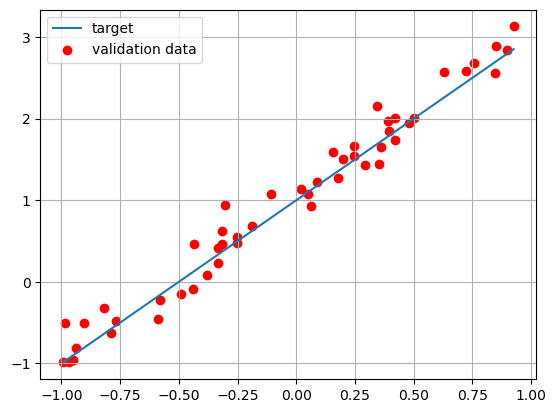

In [4]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target') #plotto funzione ideale
plt.scatter(x_valid, y_valid, color='r', label='validation data')  #disegno i punti del dataset di validazione
plt.legend()
plt.grid(True)
plt.show()

**COSTRUZIONE E COMPILAZIONE DEL MODELLO**

Poiché si tratta di una retta, è sufficiente un singolo neurone in un unico layer denso. Il modello viene compilato usando l'ottimizzatore Stochastic Gradient Descent (sgd) e la funzione di costo Mean Square Error (mse).

Lo Stochastic Gradient Descent è un ottimizzatore, ovvero è un algoritmo che ha come compito regolare i parametri della rete neurale per minimizzare l'errore commesso durante il training, misurato tramite la funzione di loss mse. In particolare, questo algoritmo lavora iterativamente:ad ogni step "sposta" i parametri della rete lungo la superficie della funzione di costo verso il punto di minimo, permettendo al modello di fittare meglio i dati osservati.

In [5]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,))) #in input solo un numero
model.add(Dense(1))  #layer con un solo neurone

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

In [6]:
# get a summary of our composed model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

**TRAINING DEL MODELLO**

In questa fase, il modello impara i pesi cercando di minimizzare il Mean Square Error. È importante monitorare sia il loss (sui dati di training) che il val_loss (sui dati di validazione).

I dati stampati mostrano, epoca per epoca, quanto bene la rete sta imparando. In generale, notiamo che:
- LOSS: diminuisce progressivamente all'aumentare delle epoche. Ovvero, all'aumentare delle epoche la rete sbaglia mediamente meno sui dati di training.
- VALIDATION LOSS: diminuisce progressivamente all'aumentare delle epoche. Ovvero, all'aumentare delle epoche la rete sbaglia meno su dati mai visti.

In [7]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=N_epochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

#per ognuno dei 32 batch la rete calcola le predizioni, valuta l'errore e aggiorna i parametri

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.3092 - mse: 1.3092 - val_loss: 1.0351 - val_mse: 1.0351
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8607 - mse: 0.8607 - val_loss: 0.7032 - val_mse: 0.7032
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5960 - mse: 0.5960 - val_loss: 0.5003 - val_mse: 0.5003
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4324 - mse: 0.4324 - val_loss: 0.3733 - val_mse: 0.3733
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3280 - mse: 0.3280 - val_loss: 0.2868 - val_mse: 0.2868
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2561 - mse: 0.2561 - val_loss: 0.2274 - val_mse: 0.2274
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2061 - mse: 0.2061 - val_loss: 0.1847 - val_mse: 0.1847
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1694 - mse: 0.1694 - val_loss: 0.1531 - val_mse: 0.1531
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.141

**VALUTAZIONE E SPIEGAZIONE DEI RISULTATI**

Per capire se il fit è riuscito, bisogna controllare peso e bias finali del neurone: il primo rappresenta il coefficiente angolare ($m$) e il secondo l'intercetta ($b$): per capire se il fit è migliorato, dobbiamo controllare quanto i pesi finali si avvicinano a m=2 e b=1.

In [8]:
# return weights and biases
model.get_weights()

[array([[1.9706658]], dtype=float32), array([0.97745675], dtype=float32)]

In [9]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0448 - mse: 0.0448

Test loss: 0.04479013755917549
Test accuracy: 0.04479013755917549


In [10]:
# evaluate model with the exact curve (uso y_target)
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 7.1345e-04 - mse: 7.1345e-04

Test loss: 0.0007134543848223984
Test accuracy: 0.0007134543848223984


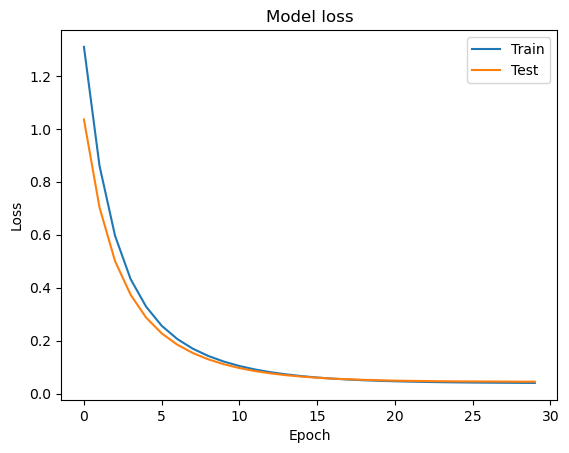

In [11]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


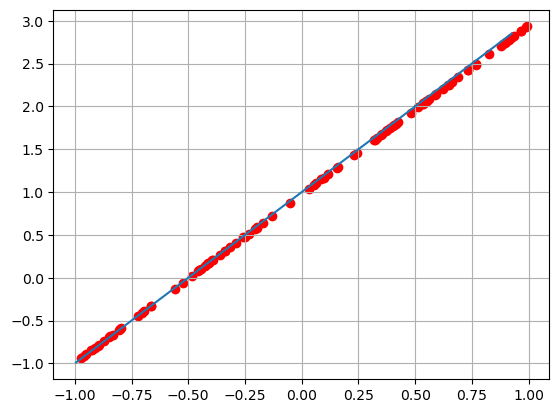

In [12]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r')
plt.plot(x_valid, y_target)
plt.grid(True)
plt.show()

**RISULTATI**

*PARAMETRI E RISULTATI*:

VARIO EPOCHE:
- N_train = 500, N_valid = 50, sigma = 0.2, N_epochs = 5: m=1.2788854; b=0.7754629
- N_train = 500, N_valid = 50, sigma = 0.2, N_epochs = 30: m=1.898277; b=0.9760032
- N_train = 500, N_valid = 50, sigma = 0.2, N_epochs = 100: m=2.0219038; b=0.9784348
- N_train = 500, N_valid = 50, sigma = 0.2, N_epochs = 500: m=2.0217135; b=0.9777636

VARIO N_TRAINS:
- N_train = 10, N_valid = 50, sigma = 0.2, N_epochs = 30: m=1.2850655; b=0.51612467
- N_train = 50, N_valid = 50, sigma = 0.2, N_epochs = 30: m=1.3094517; b=0.79991734
- N_train = 100, N_valid = 50, sigma = 0.2, N_epochs = 30: m=1.3210806; b=0.8921918
- N_train = 1000, N_valid = 50, sigma = 0.2, N_epochs = 30: m=1.9916054; b=1.0064

VARIO SIGMA:
- N_train = 500, N_valid = 50, sigma = 0., N_epochs = 30: m=1.9804784; b=0.9997148
- N_train = 500, N_valid = 50, sigma = 0.05, N_epochs = 30: m=1.9267467; b=0.99373907
- N_train = 500, N_valid = 50, sigma = 1, N_epochs = 30: m=2.0695505; b=0.8906377
- N_train = 500, N_valid = 50, sigma = 5, N_epochs = 30: m=2.4267347; b=0.44565767

**COMMENTO AI RISULTATI**

Dall’analisi dei risultati ottenuti si osserva chiaramente come la qualità della regressione dipenda in modo significativo dal numero di epoche, dal numero di dati di training e dall’intensità del rumore presente nei dati.

*EPOCHE*

Variando il numero di epoche e mantenendo fissi gli altri parametri ho notato che con un numero ridotto di epoche la rete non riesce ancora ad apprendere correttamente la relazione tra input e output. Infatti, con sole 5 epoche si ottengono valori significativamente lontani da quelli teorici (m=1.2789, b=0.7755), evidenziando una situazione di underfitting. Aumentando il numero di epoche, i parametri convergono progressivamente verso i valori corretti: già con 30 epoche il fit risulta molto buono, mentre con 100 epoche si ottiene praticamente la convergenza completa (m$\sim$2, b$\sim$1). Portando il numero di epoche fino a 500 non si osservano miglioramenti significativi, segno che il modello aveva già raggiunto una soluzione stabile e ottimale.

*TRAIN*

Anche il numero di dati di training influenza fortemente le prestazioni della rete. Con pochi punti di training il modello non dispone di informazioni sufficienti per ricostruire accuratamente la funzione lineare e il rumore incide in maniera molto marcata sui parametri stimati. Infatti, con N_train=10 si ottengono valori molto lontani da quelli teorici (m=1.2851, b=0.5161). Aumentando gradualmente il numero di dati, il fit migliora progressivamente e i parametri diventano più stabili. Con N_train=1000 la rete riesce invece a riprodurre quasi perfettamente la relazione lineare (m=1.9916, b=1.0064). Questo comportamento mostra come una maggiore quantità di dati permetta alla rete di mediare meglio gli effetti del rumore e migliorare la capacità di generalizzazione.


*RUMORE*

Infine, l’effetto del rumore è particolarmente evidente variando il parametro $\sigma$. In assenza di rumore ($\sigma$=0) la rete apprende la funzione quasi perfettamente, ottenendo valori molto vicini a quelli teorici (m=1.9805, b=0.9997). Con un rumore non nullo ma comunque piccolo ($\sigma$=0.05 e $\sigma$=0.2) il fit rimane comunque accurato, anche se i parametri iniziano a discostarsi leggermente dai valori ideali. Quando il rumore diventa elevato ($\sigma$=1 e soprattutto $\sigma$=5), la dispersione dei dati aumenta notevolmente e la rete incontra maggiori difficoltà nell’individuare la vera relazione lineare. In particolare, per $\sigma$=5 si osserva una deviazione significativa dei parametri stimati (m=2.4267, b=0.4457), indice del fatto che il rumore domina il segnale utile contenuto nei dati.

Nel complesso, i risultati ottenuti mostrano che una rete neurale semplice è perfettamente in grado di apprendere una relazione lineare, ma la qualità del fit dipende fortemente dalla quantità di dati disponibili, dal tempo di addestramento e dal livello di rumore presente nel dataset.

# **Esercizio 11.2**

**OBIETTIVI**

In questo esercizio devo provare ad estendere il modello per ottenere un fit ragionevole del seguente polinomio di terzo grado:
$$f(x) = 4 - 3x - 2x^2 + 3x^3$$
per $x \in [-1, 1]$.

In particolare, devo trovare delle buone scelte per:
-   Il numero di layer e di neuroni per layer.
-   La funzione di attivazione.
-   L'ottimizzatore e la funzione loss.

**IMPLEMENTAZIONE**

Nel caso della regressione lineare era sufficiente un singolo neurone; al contrario, per approssimare una funzione non lineare è necessario utilizzare una rete neurale più complessa, dotata di uno o più strati nascosti (gli “hidden layers”) e funzioni di attivazione non lineari.

Questo risultato è legato al Teorema di Approssimazione Universale, secondo il quale una rete neurale con almeno uno strato nascosto e un numero sufficiente di neuroni può approssimare arbitrariamente bene qualsiasi funzione continua su un intervallo limitato. Tuttavia, all’aumentare della complessità della funzione da riprodurre, aumenta anche la complessità richiesta al modello, sia in termini di numero di neuroni sia di profondità della rete.

Nel caso del polinomio cubico, un singolo neurone non sarebbe sufficiente, poiché esso può rappresentare soltanto trasformazioni lineari: gli hidden layers permettono invece alla rete di costruire l’approssimazione della curva in questione.

In particolare, ho provato diverse configurazioni di numero di hidden layers e numero di neuroni per hidden layers per trovare i parametri ottimali, con particolare attenzione a quale scelta abbassava magggiormente il valore di validation loss e di validation mse, che quantificano quanto bene la rete generalizza su dati mai visti. Inoltre, per valutare la bontà della scelta dei parametri, mi sono basata anche sul grafico che mostra l'andamento di Loss in funzione dell'epoca, sia per la funzione train che per la validation.

**FUNZIONE DI ATTIVAZIONE**

La funzione di attivazione è una funzione applicata all'output di ciascun neurone della rete neurale, e introduce non linearità nel modello. Senza funzione di attivazione, anche una rete con molti layer si comporterebbe semplicemente come una trasformazione lineare, quindi potrebbe approssimare soltanto rette o combinazioni lineari e non, ad esempio, il polinomio di terzo grado di questo esercizio.

**OTTIMIZZATORE**

L'ottimizzatore è l’algoritmo che permette alla rete neurale di “imparare” durante il training. In pratica, l'ottimizzatore cerca i parametri migliori per minimizzare la funzione di costo: calcola l’errore, capisce in che direzione modificare i parametri, aggiorna pesi e bias, ripete il processo per molte epoche.



Provando diverse combinazioni, ho scelto di:
- utilizzare 3 hidden layers (oltre al layer di output, fatto da 1 neurone)
- utilizzare 30 neuroni per il primo, 20 per il secondo, 10 per il terzo hidden layer
- utilizzare come funzione di attivazione "tanh": ho fatto questa scelta perchè è una funzione non lineare e quindi permette alla rete neurale di apprendere tramite piccoli cambiamenti nei pesi e di curvarsi per seguire l'andamento del polinomio
- utilizzare come ottimizzatore adam: a differenza dello sgd, Adam adegua i parametri basandosi sulla memoria dei gradienti precedenti e questo porta a una convergenza più rapida e stabile in presenza di non-linearità
- utilizzare come loss e metrica mse

In [13]:
#cambio retta in polinomio, costruendo funzione che restituisca il polinomio
import numpy as np

def f(x):
    return 4-3*x-2*x**2+3*x**3

In [16]:
# parametri da variare
N_train = 3000
N_valid = 100

sigma = 0.2
N_epochs = 60

In [17]:
#imposta il seed del generatore casuale
np.random.seed(0)

#genero i dati di training casualmente (distribuiti uniformemente tra -1 e 1, ovvero sto addestrando la rete solo in questo range)
x_train = np.random.uniform(-1, 1, N_train)

#genero i dati di validazione, per testare il modello su dati non usati nel training (testo capacità di generalizzazione della rete)
x_valid = np.random.uniform(-1, 1, N_valid)

#ordino i valori di validazione in ordine crescente
x_valid.sort()

#calcolo i valori della funzione vera (valutata nei punti di validazione)
y_target = f(x_valid) 

#aggiungo ai valori di train e valid un rumore sigma
y_train = np.random.normal(f(x_train), sigma)
y_valid = np.random.normal(f(x_valid), sigma)

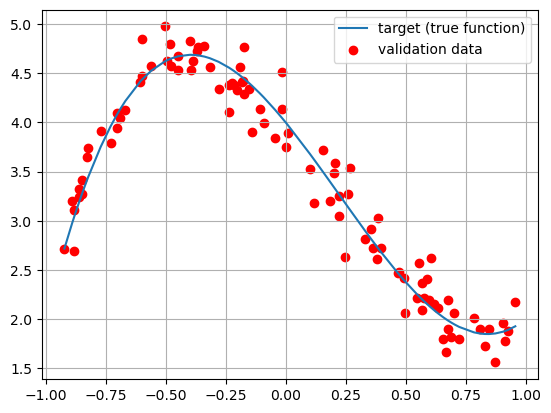

In [18]:
import matplotlib.pyplot as plt

#stampo la funzione reale
plt.plot(x_valid, y_target, label='target (true function)')

#stampo i punti di validazione (valori reali ma con rumore)
plt.scatter(x_valid, y_valid, color='r', label='validation data')

plt.legend()
plt.grid(True)
plt.show()

In [19]:
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

#creo modello neurale vuoto
model = tf.keras.Sequential()

#definisco forma input: ogni input è un singolo numero x
model.add(Input(shape=(1,)))

#costruisco primo secondo e terzo hidden layer: 30, 20, 10 neuroni con attivazione tanh (per non linearità)
model.add(Dense(30, activation='tanh'))
model.add(Dense(20, activation='tanh'))
model.add(Dense(10, activation='tanh'))

#output layer: 1 sol 
model.add(Dense(1))

In [20]:
model.compile(optimizer='adam',loss='mse',metrics=['mse'])

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 30)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 901 (3.52 KB)

 Trainable params: 901 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#addestro la rete usando dataset di training
history = model.fit(x=x_train,y=y_train,batch_size=32,epochs=N_epochs,shuffle=True,validation_data=(x_valid, y_valid))

Epoch 1/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 4.4087 - mse: 4.4087 - val_loss: 0.3388 - val_mse: 0.3388
Epoch 2/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4339 - mse: 0.4339 - val_loss: 0.2835 - val_mse: 0.2835
Epoch 3/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s -43us/step - loss: 0.3525 - mse: 0.3525 - val_loss: 0.2067 - val_mse: 0.2067
Epoch 4/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2177 - mse: 0.2177 - val_loss: 0.1166 - val_mse: 0.1166
Epoch 5/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1167 - mse: 0.1167 - val_loss: 0.0735 - val_mse: 0.0735
Epoch 6/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0773 - mse: 0.0773 - val_loss: 0.0632 - val_mse: 0.0632
Epoch 7/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0626 - mse: 0.0626 - val_loss: 0.0543 - val_mse: 0.0543
Epoch 8/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0565 - mse: 0.0565 - val_loss: 0.0536 - val_mse: 0.0536
Epoch 9/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0526 

In [23]:
#calcolo loss e mse sul dataset di validazoine
score = model.evaluate(x_valid, y_valid)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0471 - mse: 0.0471


In [24]:
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

print()
print('Validation loss (noisy data):', score[0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0471 - mse: 0.0471

Validation loss (noisy data): 0.0470765195786953


In [25]:
#confronto la rete con la funzione reale
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0028 - mse: 0.0028


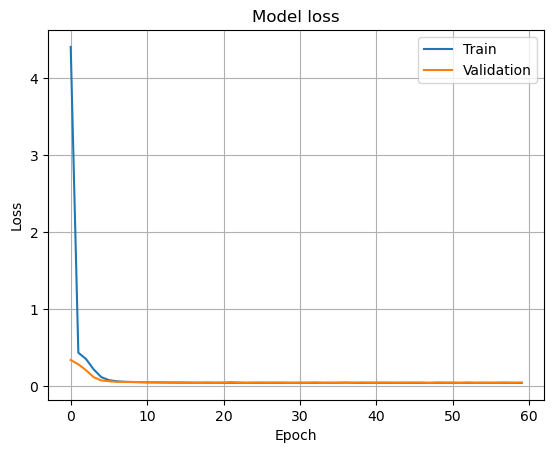

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='best')

plt.grid(True)
plt.show()

In [101]:
x_predicted = np.linspace(-1, 1, 100)  #genro 100 punti equispaziati tra -1 e 1: input per la rete
y_predicted = model.predict(x_predicted)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


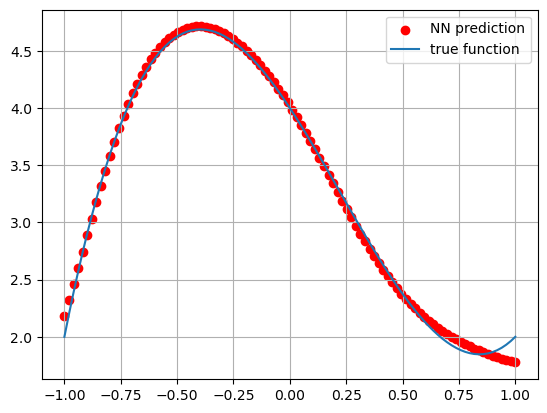

In [102]:
#stampo predizioni del modello + funzione reale per confronto
plt.scatter(x_predicted, y_predicted, color='r', label='NN prediction')
plt.plot(x_predicted, f(x_predicted), label='true function')

plt.legend()
plt.grid(True)
plt.show()

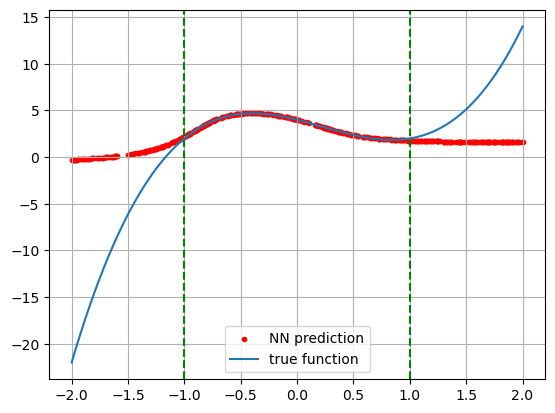

In [104]:
x_predicted = np.random.uniform(-2, 2, 500) #genero 500 punti casuali tra -2 e 2

#metto i dati nel formto richiesto
x_predicted_nn = np.array(x_predicted, dtype=np.float32).reshape(-1,1)

#uso il modello come funzione: training==false--> faccio inferenza non addestramento
y_predicted = model(x_predicted_nn, training=False).numpy().flatten()

#valori teorici
x_valid = np.linspace(-2, 2, 300)
y_target = f(x_valid) 

#stampo rette verticali in corrispondenza dei limiti dell'intervallo in cui ho allenato la rete
plt.axvline(1., color='green', linestyle='--')
plt.axvline(-1., color='green', linestyle='--')

plt.scatter(x_predicted, y_predicted, color='red', marker='.', label='NN prediction')
plt.plot(x_valid, y_target, label='true function')

plt.legend()
plt.grid(True)
plt.show()

**RISULTATI OTTENUTI**

I risultati ottenuti mostrano che la rete neurale è riuscita ad apprendere correttamente l’andamento del polinomio cubico, producendo un buon fit sia sui dati di training sia sui dati di validazione, nell'intervallo in cui è stata addetsrata. In particolare, durante il training si osserva una rapida diminuzione della loss e della validation loss nelle prime epoche, seguita da una progressiva stabilizzazione dei valori. Questo comportamento indica che la rete apprende inizialmente la struttura generale della funzione e successivamente effettua soltanto piccole correzioni sui parametri.

I valori finali di training loss e validation loss risultano inoltre molto vicini tra loro, segnale del fatto che il modello generalizza bene anche su dati non utilizzati durante l’addestramento e che non si manifesta un evidente fenomeno di overfitting. La scelta di utilizzare tre hidden layers con un numero decrescente di neuroni (30, 20 e 10) si è dimostrata efficace per rappresentare la non linearità del polinomio senza rendere il modello eccessivamente complesso.

Analizzando i grafici delle predizioni, noto che all’interno dell’intervallo di training [-1,1] la rete riproduce molto bene la funzione reale. Al contrario, fuori da questo intervallo la qualità delle predizioni peggiora in modo evidente, e la rete non è in grado di fornire una predizione accurata della funzione iniziale. Questo comportamento era atteso, poiché la rete è stata addestrata soltanto su dati appartenenti al range [-1,1] e quindi possiede informazioni limitate sul comportamento della funzione in regioni esterne. La rete neurale riesce quindi ad interpolare efficacemente i dati nel dominio di training, ma incontra maggiori difficoltà nell’estrapolazione.

# **Esercizio 11.3**

**OBIETTIVI**

In questo esercizio devo provare ad estendere il modello per fittare una funzione bidimensionale come $f(x, y) = \sin(x^2 + y^2)$ nel range $x \in [-1.5, 1.5]$ e $y \in [-1.5, 1.5]$.

**IMPLEMENTAZIONE**

Dato che devo fittare una funzione 2D, gli input non sono più una sola variabile, ma due (x e y): di conseguenza, posso vedere ogni punto come una coppia (x,y), in modo che z=f(x,y).

Per costruire il dataset, genero $N_{train}=10000$ e $N_{valid}=2000$ punti distribuiti uniformemente nel dominio. Ho scelto un numero elevato di campioni di training perché la funzione da approssimare è non lineare e dipende da due variabili: una maggiore quantità di dati permette quindi alla rete di osservare una copertura più densa dello spazio bidimensionale e di conseguenza apprendere meglio la struttura della funzione. I dati di validazione, invece, vengono usati esclusivamente per valutare la capacità di generalizzazione del modello su punti mai visti durante l’addestramento, quindi ho scelto un valore inferiore rispetto a quelli di training. Inoltre, come parametro relativo al rumore ho utilizzato $\sigma=0.1$.

La costruzione del modello richiede una rete neurale con input bidimensionale (due neuroni in ingresso) perchè ho in ingresso una coppia (x,y) di valori, e ho utilizzato due hidden layer ciascuno da 64 neuroni, per poter "imparare"/rappresentare una funzione non lineare: infatti, la funzione target richiede una combinazione non lineare delle variabili per essere approssimata correttamente.

Ho scelto come numero di epoche $N_{epochs}=100$: ho evitato un numero troppo basso, che porta a underfitting, e un numero eccessivo, che può portare a overfitting senza miglioramenti significativi.

Per quanto riguarda la rappresentazione della funzione, ho utilizzato meshgrid per costruire una griglia regolare nel dominio bidimensionale. Questo mi permette di valutare la funzione su combinazioni possibili di x e y, ottenendo così una superficie continua.

Poiché la rete neurale accetta in input solo vettori di coppie e non matrici, trasformo questa griglia tramite ravel() e column_stack, convertendo la struttura in una lista di punti (x,y). Le predizioni del modello vengono poi riportate alla forma matriciale originale tramite reshape, così da poter essere visualizzate come superficie tridimensionale.

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# funzione target: definisco la funzione che la rete deve imparare
def f(x, y):
    return np.sin(x**2 + y**2)

# parametri: punti da usare nel training e nella validazione
N_train = 10000
N_valid = 2000
sigma=0.1

# genero casualmente i punti di training nel dominio
x_train = np.random.uniform(-1.5, 1.5, N_train)
y_train = np.random.uniform(-1.5, 1.5, N_train)

# genero casualmente i punti di validazione nel dominio
x_valid = np.random.uniform(-1.5, 1.5, N_valid)
y_valid = np.random.uniform(-1.5, 1.5, N_valid)

# calcolo i valori veri della funzione per i punti del training e del validation
z_train = np.random.normal(f(x_train, y_train),sigma)
z_valid = np.random.normal(f(x_valid, y_valid),sigma)

# costruisco l'input della rete: la funzione da imparare è 2D, quindi devo dare in pasto alla rete due valoori (x e y)
#np.stack combina i valori in una matrice
X_train = np.stack([x_train, y_train], axis=1)
X_valid = np.stack([x_valid, y_valid], axis=1)

In [141]:
model = Sequential([
    Input(shape=(2,)),          #devo impostare shape=2 perchè perchè la rete deve ricevere due input, ovvero x e y
    Dense(64, activation='tanh'), #uso come funione di attivazione tanh
    Dense(64, activation='tanh'),
    Dense(1)  #l'output layer deve essere 1 perchè la rete deve restituire un solo valore
])

In [142]:
model.compile(optimizer='adam',loss='mse')

In [143]:
#addestramento della rete
#la rete riceve gli input, fa 100 epoche e aggiorna i prametri dopo 32 dati
history = model.fit(X_train, z_train,validation_data=(X_valid, z_valid),N_epochs=100,batch_size=64,verbose=1)

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1937 - val_loss: 0.1650
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1592 - val_loss: 0.1686
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1585 - val_loss: 0.1698
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1596 - val_loss: 0.1655
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1589 - val_loss: 0.1704
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1585 - val_loss: 0.1665
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1586 - val_loss: 0.1667
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1588 - val_loss: 0.1656
Epoch 9/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1582 - val_loss: 0.1696
Epoch 10/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1581 - val_loss: 0.1661
Epoch 11/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1587 - val_loss: 0.1646
Epoch 12/100
157/157 ━━━━━━━━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


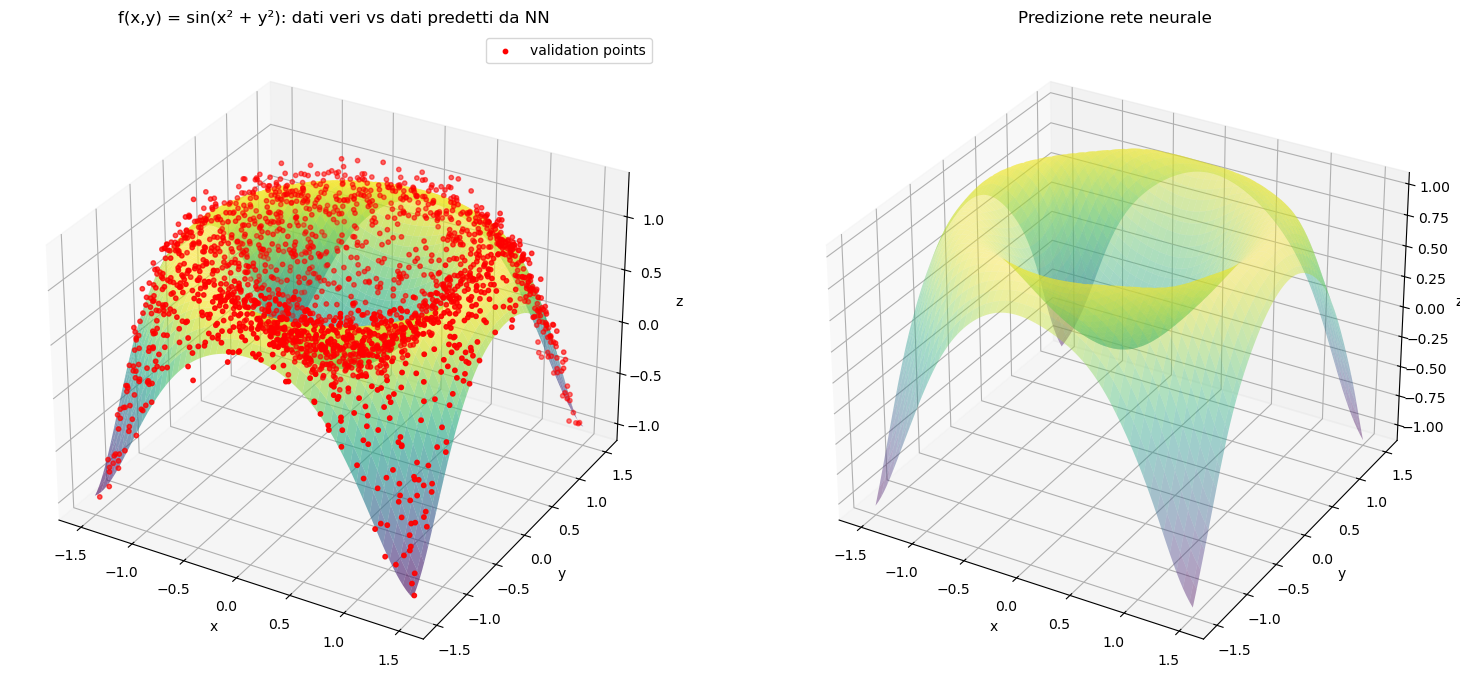

In [145]:
#creo assi + dominio funzione
x_plot = np.linspace(-1.5, 1.5, 100)
y_plot = np.linspace(-1.5, 1.5, 100)

#costruisco griglia 2D con le combinazioni per le coppie x,y: ogni punto è una coppia (x,y) in cui valuterò la funzione
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

#costruisco funzione reale
Z_true = f(X_plot, Y_plot)

#scrivo i punti in modo che siano "leggibili" dalla rete: la rete no legge matrici ma liste, quindi ho trasformato la matrice in due liste
XY_plot = np.column_stack((X_plot.ravel(), Y_plot.ravel()))

#valori predetti dalla rete (li riporto in matrice usando reshape)
Z_pred = model.predict(XY_plot).reshape(X_plot.shape)

#creo grafico
fig = plt.figure(figsize=(16, 7))

#superficie vera
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(X_plot, Y_plot, Z_true, cmap='viridis', alpha=0.6)

# punti di validation
ax.scatter(x_valid, y_valid, z_valid, color='red', s=10, label='validation points')
plt.legend()

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set_title('f(x,y) = sin(x² + y²): dati veri vs dati predetti da NN')

# superficie predetta
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_plot, Y_plot, Z_pred, cmap='viridis', alpha=0.4)

ax2.set_title("Predizione rete neurale")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")

plt.tight_layout()
plt.show()

**COMMENTO AI RISULTATI**

I risultati ottenuti mostrano che la rete neurale è in grado di approssimare in modo piuttosto accurato la funzione bidimensionale richiesta, all’interno del dominio di training $x,y \in [-1.5, 1.5]$. Infatti, come si osserva dal confronto delle due rappresentazioni, la superficie predetta segue correttamente l’andamento generale della funzione reale, indicando che il modello ha appreso la struttura non lineare del problema.

In particolare, durante l’addestramento si osserva una diminuzione progressiva della loss e della validation loss nelle prime $\sim 40$ epoche, seguita da una fase di stabilizzazione. Questo comportamento indica che il modello riesce inizialmente a catturare le caratteristiche principali della funzione e successivamente converge verso una rifinitura dei pesi. La vicinanza tra loss e validation loss suggerisce inoltre una buona capacità di generalizzazione rispetto a quanto sta memorizzando i dati di training, indicando che il modello ha effettivamente appreso la struttura della funzione.

Dunque, dall’analisi dei grafici 3D emerge che, all’interno dell’intervallo in cui il modello è stato addestrato, la superficie predetta è molto simile a quella reale, e anche i punti di validazione risultano coerenti con l’andamento della funzione. Questo conferma che la rete ha imparato una buona rappresentazione della mappatura bidimensionale.